# Student Performance Analysis Notebook

In [66]:
import pandas as pd
import numpy as np
import sqlite3

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

## 1. Setup and Library Imports


In [67]:
print("="*60)
print("STUDENT ANALYTICS SYSTEM")
print("="*60)

df = pd.read_csv("student_performance.csv")

print("\nDataset Loaded Successfully")

STUDENT ANALYTICS SYSTEM

Dataset Loaded Successfully


## 2. Data Loading and Initial Inspection


In [68]:
print("\nFirst 5 Records")
display(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nColumn Names")
print(df.columns)

print("\nDataset Information")
df.info()

print("\nStatistical Summary")
display(df.describe())


First 5 Records


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023



Dataset Shape
(30, 13)

Column Names
Index(['student_id', 'name', 'age', 'gender', 'department', 'semester',
       'math_score', 'science_score', 'english_score', 'programming_score',
       'attendance_percentage', 'city', 'admission_year'],
      dtype='object')

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   student_id             30 non-null     int64 
 1   name                   30 non-null     object
 2   age                    30 non-null     int64 
 3   gender                 30 non-null     object
 4   department             30 non-null     object
 5   semester               30 non-null     int64 
 6   math_score             30 non-null     int64 
 7   science_score          30 non-null     int64 
 8   english_score          30 non-null     int64 
 9   programming_score      30 non-null     int6

,student_id,age,semester,math_score,science_score,english_score,programming_score,attendance_percentage,admission_year
count,30.000000,30.000000,30.0,30.000000,30.000000,30.000000,30.000000,30.000000,30.0
mean,1015.500000,19.733333,2.0,76.066667,77.833333,74.166667,67.600000,84.500000,2023.0
std,8.803408,0.739680,0.0,11.467896,8.554423,10.003735,21.041175,9.379913,0.0
min,1001.000000,19.000000,2.0,56.000000,61.000000,55.000000,38.000000,65.000000,2023.0
25%,1008.250000,19.000000,2.0,67.250000,71.250000,67.250000,49.250000,77.250000,2023.0
50%,1015.500000,20.000000,2.0,75.500000,78.000000,75.000000,66.000000,86.500000,2023.0
75%,1022.750000,20.000000,2.0,85.750000,83.750000,81.750000,88.750000,91.750000,2023.0
max,1030.000000,21.000000,2.0,95.000000,93.000000,90.000000,97.000000,98.000000,2023.0


In [69]:

df['total_score'] = df['math_score'] + df['science_score'] + df['english_score'] + df['programming_score']

print("DataFrame with 'total_score' column added:")
display(df.head())

DataFrame with 'total_score' column added:


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year,total_score
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023,326
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023,325
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023,255
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023,273
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023,356


## 3. Data Preprocessing
This section involves adding a `total_score` column to the DataFrame by summing individual subject scores and checking for missing values and duplicate records.

In [70]:
print("\nMissing Values")

display(df.isnull().sum())

print("\nDuplicate Records")

print(df.duplicated().sum())


Missing Values


,0
student_id,0
name,0
age,0
gender,0
department,0
semester,0
math_score,0
science_score,0
english_score,0
programming_score,0



Duplicate Records
0


## 4. Store Data in SQLite Database

In [71]:
conn = sqlite3.connect("student_database.db")

df.to_sql(
    "students",
    conn,
    if_exists="replace",
    index=False
)

print("Data Stored Successfully")

Data Stored Successfully


## 5. Perform SQL Queries for Data Analysis


In [72]:
query = """
SELECT department,
AVG(math_score + science_score + english_score + programming_score) AS average_score
FROM students
GROUP BY department
"""

display(pd.read_sql_query(query, conn))

,department,average_score
0,Civil,235.800000
1,Computer Science,340.153846
2,Electronics,277.500000
3,Mechanical,267.333333


In [73]:
query = """
SELECT department,
AVG(math_score + science_score + english_score + programming_score) AS average_score
FROM students
GROUP BY department
"""

display(pd.read_sql_query(query, conn))

,department,average_score
0,Civil,235.800000
1,Computer Science,340.153846
2,Electronics,277.500000
3,Mechanical,267.333333


In [74]:
query = """
SELECT name,
department,
(math_score + science_score + english_score + programming_score) AS total_score
FROM students
ORDER BY total_score DESC
LIMIT 5
"""

display(pd.read_sql_query(query, conn))

,name,department,total_score
0,Ananya Das,Computer Science,371
1,Tanvi Mehta,Computer Science,367
2,Akanksha Yadav,Computer Science,365
3,Arjun Nair,Computer Science,356
4,Divya Singh,Computer Science,356


In [75]:
query = """
SELECT department,
COUNT(*) AS total_students
FROM students
GROUP BY department
"""

display(pd.read_sql_query(query, conn))

,department,total_students
0,Civil,5
1,Computer Science,13
2,Electronics,6
3,Mechanical,6


In [76]:
query = """
SELECT name,
attendance_percentage
FROM students
ORDER BY attendance_percentage DESC
LIMIT 5
"""

display(pd.read_sql_query(query, conn))

,name,attendance_percentage
0,Ananya Das,98
1,Tanvi Mehta,97
2,Divya Singh,96
3,Sneha Reddy,95
4,Akanksha Yadav,95


## 6. Data Visualization


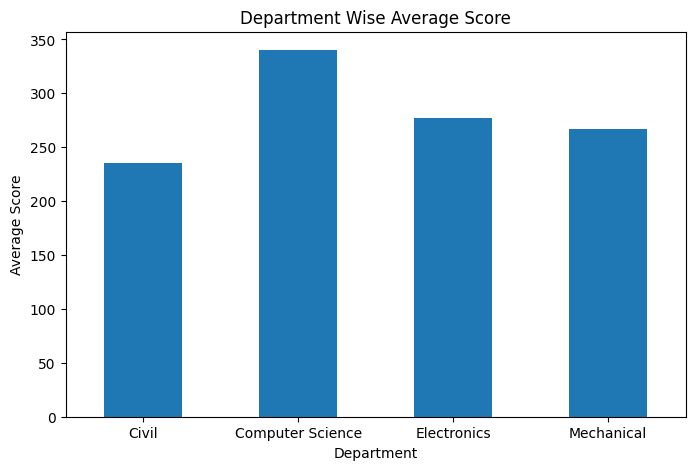

In [77]:
dept_avg = df.groupby("department")["total_score"].mean()

plt.figure(figsize=(8,5))
dept_avg.plot(kind="bar")

plt.title("Department Wise Average Score")
plt.xlabel("Department")
plt.ylabel("Average Score")
plt.xticks(rotation=0, ha='center')

plt.show()

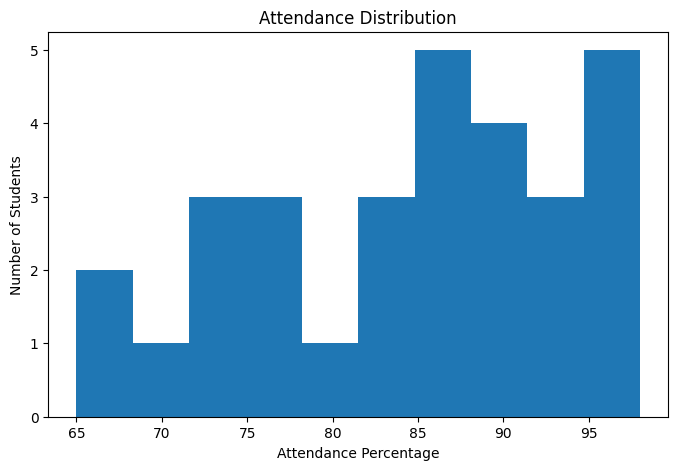

In [78]:
plt.figure(figsize=(8,5))

plt.hist(df["attendance_percentage"], bins=10)

plt.title("Attendance Distribution")
plt.xlabel("Attendance Percentage")
plt.ylabel("Number of Students")

plt.show()

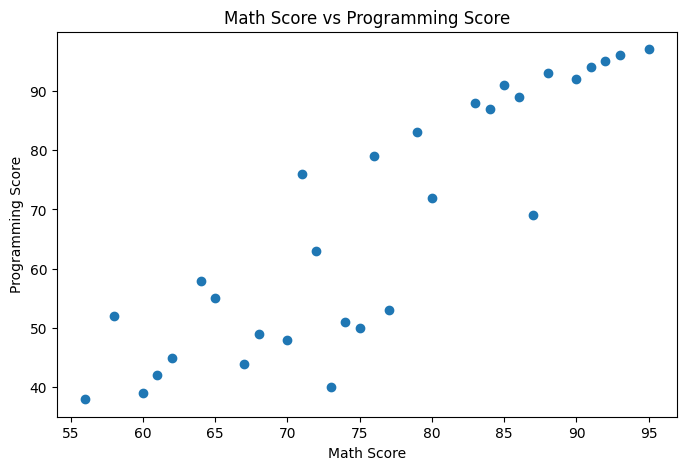

In [79]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["math_score"],
    df["programming_score"]
)

plt.title("Math Score vs Programming Score")
plt.xlabel("Math Score")
plt.ylabel("Programming Score")

plt.show()

## 7. Machine Learning Model for Programming Score Prediction


In [80]:
X = df[
    [
        "math_score",
        "attendance_percentage",
        "total_score"
    ]
]

y = df["programming_score"]

In [81]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [82]:
model = RandomForestRegressor(
    random_state=42
)

model.fit(
    X_train,
    y_train
)

RandomForestRegressor(random_state=42)

## 8. Model Training, Prediction, and Evaluation


In [83]:
predictions = model.predict(X_test)

In [84]:
mae = mean_absolute_error(
    y_test,
    predictions
)

r2 = r2_score(
    y_test,
    predictions
)

print("Mean Absolute Error:", round(mae,2))
print("R2 Score:", round(r2,2))

Mean Absolute Error: 7.71
R2 Score: 0.77


In [85]:
sample = [[85, 92, 177]]

prediction = model.predict(sample)

print(
    "Predicted Programming Score:",
    round(prediction[0],2)
)

Predicted Programming Score: 63.95


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


## 9. Business Insights Report


In [86]:
print("="*60)
print("BUSINESS INSIGHTS REPORT")
print("="*60)

print(
    "Total Students:",
    len(df)
)

print(
    "Average Total Score:",
    round(df["total_score"].mean(),2)
)

best_department = df.groupby(
    "department"
)["total_score"].mean().idxmax()

print(
    "Best Performing Department:",
    best_department
)

top_student = df.loc[
    df["total_score"].idxmax(),
    "name"
]

print(
    "Top Performing Student:",
    top_student
)

BUSINESS INSIGHTS REPORT
Total Students: 30
Average Total Score: 295.67
Best Performing Department: Computer Science
Top Performing Student: Ananya Das
